**Overview**  
This notebook describes folloiwing stages:
1. Creating functions to:
    - perform search for optimal algorithm parameters;
    - train model;
    - calculate the most important metrics;
    - plot ROC-AUC curve
2. Assess the results of following algorithms:
    - Logistic regression;
    - Random Forest;
    - Gradient Boosting as implemented in XGBoost;
    - Support Vector Machines;
    - K-Nearest Neighborrs
3. Creare dataframe with the main indiators of models' performance


In [10]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsRegressor
from textwrap import wrap

First, let's import datasets and y-target, created earlier:

In [11]:
with open ('rdkit_descs.pickle', 'rb') as inp:
    rdkit_descs = pickle.load(inp)

In [12]:
data_ionic = pd.read_csv('Data_ionic.csv')
target_ionic = data_ionic['Cc ']

data_extended = pd.read_csv('Data_extended.csv')
target_extended = data_extended['Cc ']

data_non_ionic = pd.read_csv('Data_non_ionic.csv')
target_non_ionic = data_non_ionic['Cc ']

targets = {'RDKIt_ionic': target_ionic, 'RDKIt_non_ionic': target_non_ionic, 'RDKIt_extended':target_extended}

In [22]:
scores_ionic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_non_ionic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_extended = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores = {'RDKIt_ionic': scores_ionic, 'RDKIt_non_ionic': scores_non_ionic, 'RDKIt_extended':scores_extended}

In [23]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']

In [24]:
def calculate_to_score(estimator, estimator_name, param_grid, descriptors_dict = rdkit_descs, targets = targets, n_iters = 3):
    fig, axes = plt.subplots(1, 3, figsize = (12,8))
    i = 0
    
    for key, value in descriptors_dict.items():
        target = targets[key]
        X_train, X_test, y_train, y_test = train_test_split(value, target, random_state = 0)
        def objective(params, X, target):
            pipe = make_pipeline(StandardScaler(), estimator)
            pipe.set_params(**params)
            y_cv_pred = cross_val_predict(pipe, X, target, cv=5)
            cv_rmse = np.sqrt(root_mean_squared_error(target, y_cv_pred))
            cv_r2 = r2_score(target, y_cv_pred)
            
            score = cross_val_score(pipe, X, target, cv = 10, scoring = 'neg_mean_absolute_error')
            return {'loss':-score.mean(), 'status':STATUS_OK, 'Trained_model':pipe, 'rmse':cv_rmse, 'r2':cv_r2}
        
        trials = Trials()
        best = fmin(partial(objective, X = X_train, target = y_train), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  n_iters)
        print(best)
        
        best_estimator  = get_best_model_from_trials(trials)['Trained_model']
      
        
        cv_r2 = get_best_model_from_trials(trials)['r2']
        cv_rmse = get_best_model_from_trials(trials)['rmse']
        cv_mae = get_best_model_from_trials(trials)['loss']
        
        scores[key]['Descriptors'].append('RDKit')
        scores[key]['R2_cv'].append(cv_r2)
        scores[key]['RMSE_cv'].append(cv_rmse)
        scores[key]['MAE_cv'].append(cv_mae)
        
        best_estimator.fit(X_train, y_train)
        predictions = best_estimator.predict(X_test)
        predictions_train = best_estimator.predict(X_train)
        scores[key]['Estimator'].append(estimator_name)
        scores[key]['R2_test'].append(r2_score(y_test, predictions))
        scores[key]['R2_train'].append(r2_score(y_train, predictions_train))
        
        scores[key]['RMSE_test'].append(root_mean_squared_error(y_test, predictions))
        scores[key]['RMSE_train'].append(root_mean_squared_error(y_train, predictions_train))

        
        scores[key]['MAE_test'].append(mean_absolute_error(y_test, predictions))
        scores[key]['MAE_train'].append(mean_absolute_error(y_train, predictions_train))
        
        axes[i].plot(y_test, predictions, 'ro', label = 'Test values')
        axes[i].plot(y_train, predictions_train, 'go', label = 'Train values')
        axes[i].plot([target.min(),target.max()], [target.min(),target.max()])
        axes[i].set_title('{}'.format(key))
        axes[i].set_xlabel('True test values')
        axes[i].set_ylabel('Predicted test values')
        axes[i].legend()
        i += 1
    plt.tight_layout()
    plt.savefig('All_classes_Rdkit_{}_scattter.png'.format(estimator_name))

Subfunction below is to retrieve best model from Trials object ans is used in main functions

Let's initialize scores dictionary and test function with Logistic Regression

100%|██████████████████████████████████████████████| 150/150 [00:54<00:00,  2.77trial/s, best loss: 1.9665059073626658]
{'alpha': 70.10717442249147, 'solver': 4}
100%|███████████████████████████████████████████████| 150/150 [01:17<00:00,  1.92trial/s, best loss: 1.083903018061665]
{'alpha': 44.297088868576886, 'solver': 5}
100%|██████████████████████████████████████████████| 150/150 [00:19<00:00,  7.88trial/s, best loss: 0.9242664045623746]
{'alpha': 99.98934078198128, 'solver': 2}


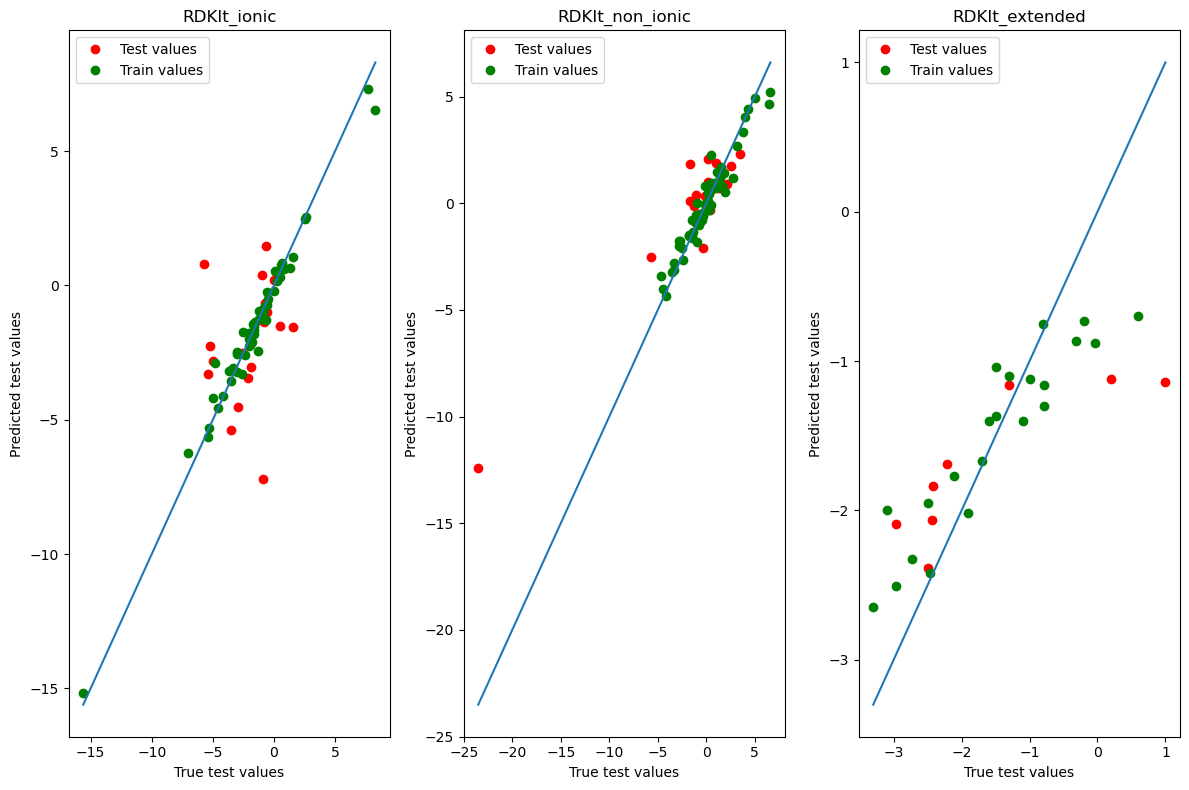

In [25]:
calculate_to_score(Ridge(max_iter = 10000), estimator_name='Linear Regression', 
                   param_grid = {'ridge__alpha':hp.loguniform(label = 'alpha', low = -4*np.log(10), high  = 2*np.log(10)),
                                'ridge__solver':hp.choice(label = 'solver', options = ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg','sag', 'saga'])}, n_iters=150)

Let's continue with other models. The first one will be
**Random Forest Classification**

In [26]:
space = {
    'randomforestregressor__max_depth': hp.randint('max_depth', 3, 15),  
    'randomforestregressor__max_features': hp.choice('max_features', [0.3, 0.5, 'sqrt', 'log2']), 
    'randomforestregressor__min_samples_split': hp.randint('min_samples_split', 5, 20),  
    'randomforestregressor__min_samples_leaf': hp.randint('min_samples_leaf', 3, 10), 
    'randomforestregressor__criterion': hp.choice('criterion', ["squared_error", "absolute_error"]), 
    'randomforestregressor__ccp_alpha': hp.uniform('ccp_alpha', 0, 0.1),  
    'randomforestregressor__n_estimators': hp.randint('n_estimators', 50, 200),  
    'randomforestregressor__bootstrap': hp.choice('bootstrap', [True]),  
    'randomforestregressor__max_samples': hp.uniform('max_samples', 0.6, 0.95)} 

100%|██████████████████████████████████████████████████| 3/3 [00:06<00:00,  2.05s/trial, best loss: 1.9582755718657316]
{'bootstrap': 0, 'ccp_alpha': 0.011384150727826937, 'criterion': 0, 'max_depth': 11, 'max_features': 0, 'max_samples': 0.6556090195616046, 'min_samples_leaf': 5, 'min_samples_split': 11, 'n_estimators': 121}
100%|██████████████████████████████████████████████████| 3/3 [00:06<00:00,  2.28s/trial, best loss: 1.4233608869206984]
{'bootstrap': 0, 'ccp_alpha': 0.06303035662521124, 'criterion': 0, 'max_depth': 6, 'max_features': 1, 'max_samples': 0.7276698082278815, 'min_samples_leaf': 7, 'min_samples_split': 10, 'n_estimators': 138}
100%|██████████████████████████████████████████████████| 3/3 [00:05<00:00,  1.93s/trial, best loss: 0.8229990083426122]
{'bootstrap': 0, 'ccp_alpha': 0.06538404072321743, 'criterion': 0, 'max_depth': 14, 'max_features': 0, 'max_samples': 0.8568661011242253, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 85}


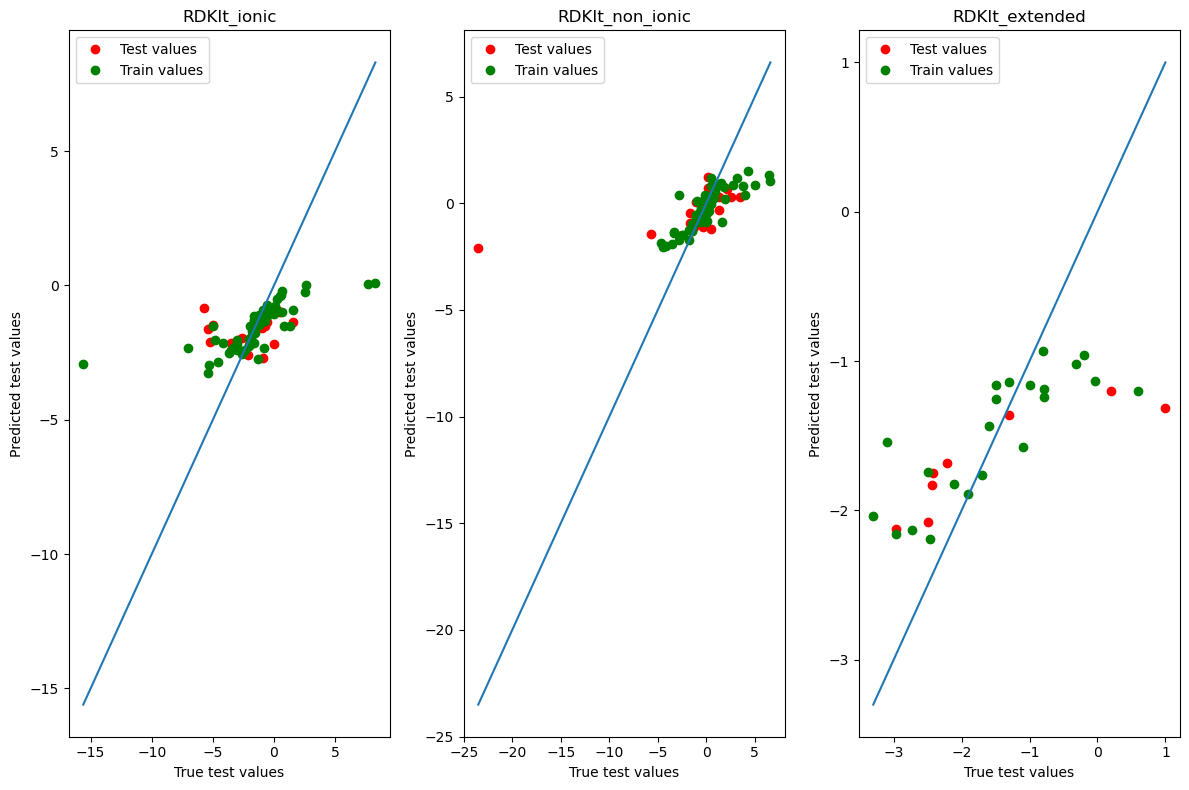

In [27]:
calculate_to_score(RandomForestRegressor(random_state = 0, n_jobs=-1), estimator_name = 'Random Forest', param_grid =  space)
               

**LightGBM**

In [28]:
space = {'lgbmregressor__max_depth':hp.randint('max_depth', 3, 12),
        'lgbmregressor__boosting_type':hp.choice('boosting_type', ['gbdt']),
        'lgbmregressor__reg_alpha':hp.loguniform('reg_alpha', -3*np.log(10), 1*np.log(10)),
         'lgbmregressor__reg_lamdba':hp.loguniform('reg_lambda', -3*np.log(10), 1*np.log(10)),
        'lgbmregressor__learning_rate':hp.loguniform('learning_rate', -3*np.log(10), 1*np.log(10)),
        'lgbmregressor__n_estimators':hp.randint('n_estimators', 50, 300),
        'lgbmregressor__n_leaves':hp.randint('n_leaves', 10, 50),
        'lgbmregressor__min_child_samples': hp.randint('min_child_samples', 5, 30)}

100%|███████████████████████████████████████████████████| 3/3 [00:01<00:00,  1.83trial/s, best loss: 2.091297145654587]
{'boosting_type': 0, 'learning_rate': 0.0017834815264566731, 'max_depth': 5, 'min_child_samples': 21, 'n_estimators': 79, 'n_leaves': 10, 'reg_alpha': 0.01526408972108189, 'reg_lambda': 4.484844104156757}
100%|██████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.52trial/s, best loss: 1.5451666213481736]
{'boosting_type': 0, 'learning_rate': 0.02239542237852998, 'max_depth': 9, 'min_child_samples': 23, 'n_estimators': 78, 'n_leaves': 10, 'reg_alpha': 0.00254601323878292, 'reg_lambda': 0.5438175875060897}
100%|██████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.68trial/s, best loss: 0.8934868721504964]
{'boosting_type': 0, 'learning_rate': 0.0024917071244128387, 'max_depth': 11, 'min_child_samples': 28, 'n_estimators': 137, 'n_leaves': 22, 'reg_alpha': 0.053751603985737945, 'reg_lambda': 0.08741561910208778}


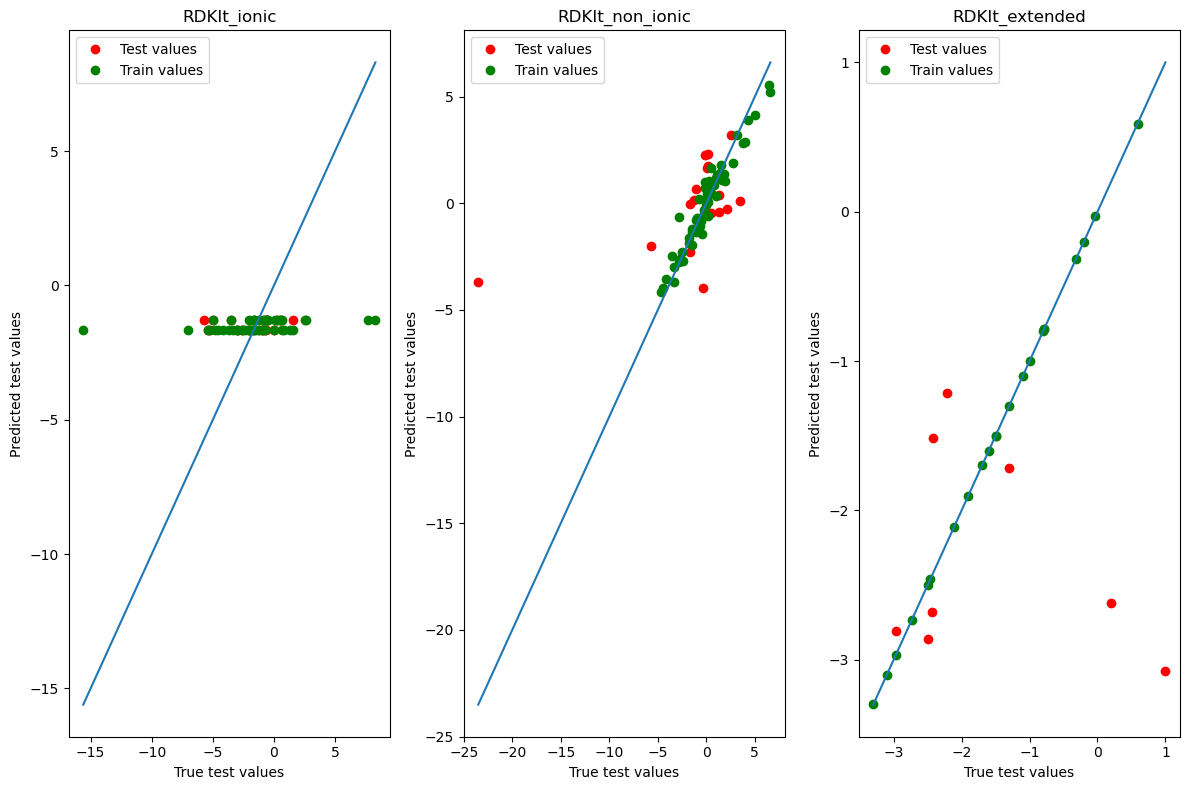

In [29]:
calculate_to_score(LGBMRegressor(verbosity = -1), estimator_name='Gradient boosting', param_grid = space)

**SVM**

In [30]:
space = {'svr__C':hp.loguniform('C', -2*np.log(10), 1*np.log(10)),
         'svr__kernel':hp.choice('kernel', ['rbf','poly','linear', 'sigmoid']),
         'svr__degree':hp.choice('degree', [2,3,4]),
         'svr__gamma':hp.choice('gamma', ['scale', 'auto']),
         'svr__coef0':hp.loguniform('coef0', -1, 1)}


100%|██████████████████████████████████████████████| 500/500 [01:05<00:00,  7.69trial/s, best loss: 1.5827823895991524]
{'C': 1.644535139025849, 'coef0': 1.848926266601205, 'degree': 1, 'gamma': 1, 'kernel': 1}
100%|███████████████████████████████████████████████| 500/500 [01:12<00:00,  6.86trial/s, best loss: 1.018004195835141]
{'C': 0.030722608796661527, 'coef0': 1.064299618066061, 'degree': 2, 'gamma': 1, 'kernel': 2}
100%|███████████████████████████████████████████████| 500/500 [01:06<00:00,  7.53trial/s, best loss: 0.760999150899818]
{'C': 3.4368990109875868, 'coef0': 2.2493651458598656, 'degree': 0, 'gamma': 0, 'kernel': 3}


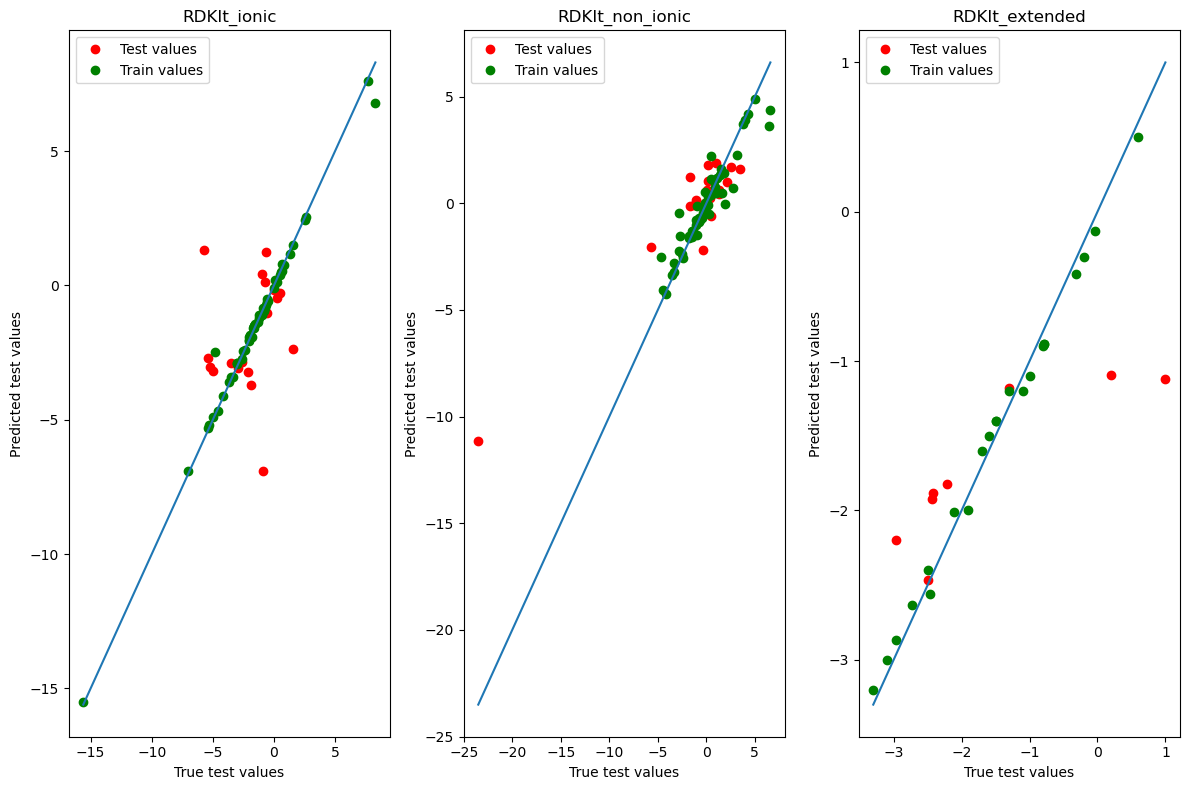

In [31]:
calculate_to_score(SVR(max_iter = 15000), estimator_name = 'SVR', param_grid = space, n_iters = 500)
                                                                


**KNearestneighbors**

In [32]:
space = {
    'kneighborsregressor__n_neighbors': hp.randint('n_neighbors', 3, 16),  # Увеличил диапазон
    'kneighborsregressor__weights': hp.choice('weights', ['uniform', 'distance']),
    'kneighborsregressor__metric': hp.choice('metric', ['minkowski', 'euclidean', 'manhattan']),  # Упростил выбор
    'kneighborsregressor__p': hp.uniform('p', 1, 3),  # Параметр для minkowski
    'kneighborsregressor__algorithm': hp.choice('algorithm', ['auto', 'ball_tree', 'kd_tree']),
    'kneighborsregressor__leaf_size': hp.randint('leaf_size', 10, 50)  # Для tree-based алгоритмов
}

100%|██████████████████████████████████████████████████| 3/3 [00:00<00:00,  5.74trial/s, best loss: 1.8498680555555556]
{'algorithm': 0, 'leaf_size': 22, 'metric': 1, 'n_neighbors': 8, 'p': 1.0806759867796585, 'weights': 0}
100%|███████████████████████████████████████████████████| 3/3 [00:00<00:00,  7.42trial/s, best loss: 1.488773327024993]
{'algorithm': 0, 'leaf_size': 30, 'metric': 2, 'n_neighbors': 8, 'p': 2.9776765695750886, 'weights': 1}
100%|██████████████████████████████████████████████████| 3/3 [00:00<00:00,  7.93trial/s, best loss: 0.7278230702518308]
{'algorithm': 1, 'leaf_size': 49, 'metric': 2, 'n_neighbors': 3, 'p': 1.8203910051934864, 'weights': 1}


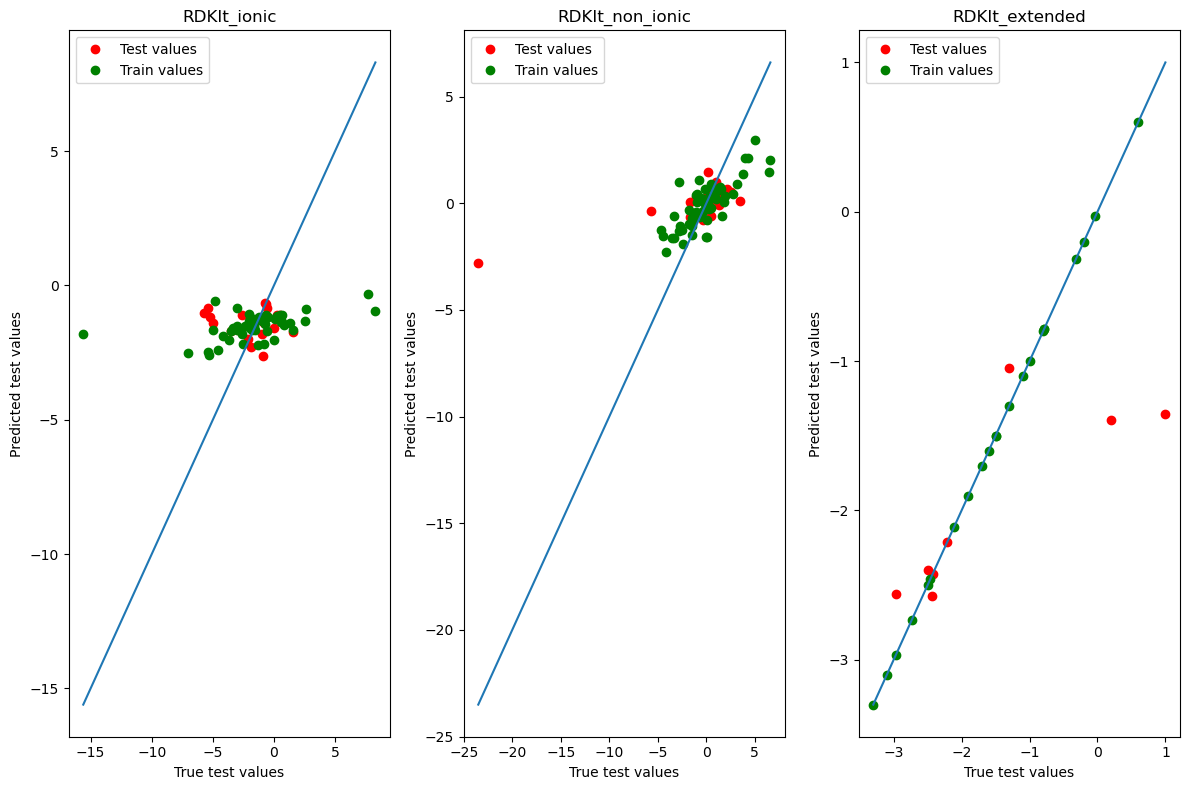

In [33]:
calculate_to_score(KNeighborsRegressor(), estimator_name='KMeans', param_grid=space)

Let's save results into pickle file and show the final scores model in readable format

In [23]:
with open('scores_rdkit_descs.pickle', 'wb') as output:
    pickle.dump(scores, output)

In [36]:
pd.DataFrame(scores_ionic)

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,RDKit,Linear Regression,0.054672,1.966506,1.793311,-0.534933,2.618644,1.907219,0.975727,0.515322,0.335586
1,RDKit,Random Forest,-0.016252,1.958276,1.826041,0.001363,2.112203,1.640152,0.322050,2.723446,1.525025
2,RDKit,Gradient boosting,-0.050463,2.091297,1.841218,-0.022576,2.137369,1.710944,0.041020,3.239104,2.021054
3,RDKit,SVR,0.111527,1.582782,1.765717,-0.521527,2.607183,1.791217,0.985881,0.393032,0.161380
4,RDKit,KMeans,0.054215,1.849868,1.793528,-0.187471,2.303262,1.750170,0.127174,3.090180,1.926656


In [34]:
pd.DataFrame(scores_non_ionic)

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,RDKit,Linear Regression,0.558966,1.083903,1.279359,0.722258,2.949801,1.762154,0.929700,0.653469,0.479945
1,RDKit,Random Forest,0.316211,1.423361,1.427595,0.151639,5.155395,2.289955,0.496520,1.748800,1.191189
2,RDKit,Gradient boosting,0.096397,1.545167,1.530625,0.217224,4.952109,2.668428,0.932046,0.642476,0.483309
3,RDKit,SVR,0.615119,1.018004,1.236534,0.671589,3.207604,1.859761,0.878100,0.860500,0.509354
4,RDKit,KMeans,0.372639,1.488773,1.397184,0.182415,5.061019,2.311671,0.513328,1.719361,1.302675


In [35]:
pd.DataFrame(scores_extended)

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,RDKit,Linear Regression,-0.055334,0.924266,1.031675,0.456971,0.992898,0.760513,0.734607,0.533747,0.422334
1,RDKit,Random Forest,-0.002471,0.822999,1.018506,0.358958,1.078788,0.855863,0.483767,0.744413,0.569710
2,RDKit,Gradient boosting,-0.088167,0.893487,1.039607,-0.842169,1.828764,1.247481,0.999992,0.002952,0.001308
3,RDKit,SVR,0.089405,0.760999,0.994321,0.485220,0.966727,0.723041,0.990703,0.099899,0.099898
4,RDKit,KMeans,0.176794,0.727823,0.969555,0.424419,1.022225,0.609184,1.000000,0.000000,0.000000
